# Dataset Inspection and Tutorial

This notebook provides an overview of the image classification dataset and demonstrates how to use it with PyTorch.

## Dataset Overview

The dataset contains **grayscale images** (128x128 pixels) for **binary classification** tasks.

There are 3 categories of data:
- **ASB** - 3,741 samples
- **NT** - 1,407 samples  
- **UT** - 881 samples

Each category has train/val/test splits (60%/20%/20%) stored in NPZ format.

### Directory Structure
```
data/processed/
├── ASB/
│   ├── train.npz  (2,244 samples)
│   ├── val.npz    (748 samples)
│   └── test.npz   (749 samples)
├── NT/
│   ├── train.npz  (844 samples)
│   ├── val.npz    (281 samples)
│   └── test.npz   (282 samples)
└── UT/
    ├── train.npz  (528 samples)
    ├── val.npz    (176 samples)
    └── test.npz   (177 samples)
```

## 1. Loading the Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load the ASB training data
data_path = Path("../data/processed/ASB/train.npz")
data = np.load(data_path)

# Access images and labels
images = data["images"]
labels = data["labels"]

print(f"Images shape: {images.shape}")  # (N, 1, 128, 128)
print(f"Labels shape: {labels.shape}")  # (N,)
print(f"Image dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")
print(f"Pixel value range: [{images.min():.2f}, {images.max():.2f}]")

Images shape: (2244, 1, 128, 128)
Labels shape: (2244,)
Image dtype: float32
Label dtype: int64
Pixel value range: [0.00, 1.00]


## 2. Data Inspection

In [3]:
# Check class distribution
unique, counts = np.unique(labels, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples ({100*c/len(labels):.1f}%)")

Class distribution:
  Class 0: 1203 samples (53.6%)
  Class 1: 1041 samples (46.4%)


In [4]:
# Load all splits and summarize
categories = ["ASB", "NT", "UT"]
splits = ["train", "val", "test"]

print("Dataset Summary:")
print("=" * 60)
for cat in categories:
    print(f"\n{cat}:")
    for split in splits:
        data = np.load(f"../data/processed/{cat}/{split}.npz")
        imgs, lbls = data["images"], data["labels"]
        class_dist = dict(zip(*np.unique(lbls, return_counts=True)))
        print(f"  {split:5s}: {len(lbls):4d} samples | Class 0: {class_dist.get(0, 0):4d}, Class 1: {class_dist.get(1, 0):4d}")

Dataset Summary:

ASB:
  train: 2244 samples | Class 0: 1203, Class 1: 1041
  val  :  748 samples | Class 0:  401, Class 1:  347
  test :  749 samples | Class 0:  402, Class 1:  347

NT:
  train:  844 samples | Class 0:  425, Class 1:  419
  val  :  281 samples | Class 0:  141, Class 1:  140
  test :  282 samples | Class 0:  142, Class 1:  140

UT:
  train:  528 samples | Class 0:  274, Class 1:  254
  val  :  176 samples | Class 0:   91, Class 1:   85
  test :  177 samples | Class 0:   92, Class 1:   85


## 3. Visualizing Sample Images

In [5]:
def show_samples(images, labels, n_samples=8, title="Sample Images"):
    """Display a grid of sample images."""
    fig, axes = plt.subplots(2, n_samples//2, figsize=(12, 5))
    axes = axes.flatten()
    
    # Get random indices
    indices = np.random.choice(len(images), n_samples, replace=False)
    
    for ax, idx in zip(axes, indices):
        # Remove channel dimension for display: (1, 128, 128) -> (128, 128)
        img = images[idx, 0]
        label = labels[idx]
        
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Label: {label}")
        ax.axis("off")
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

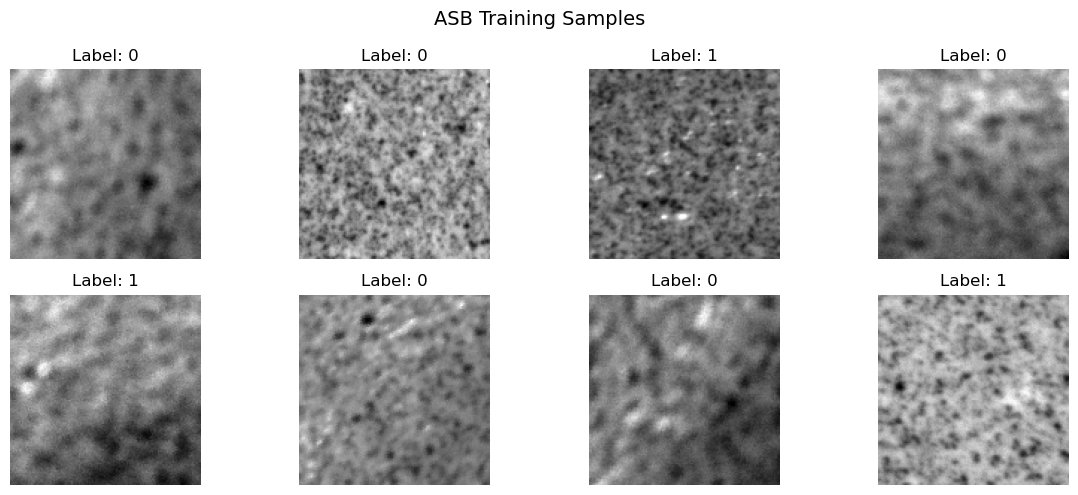

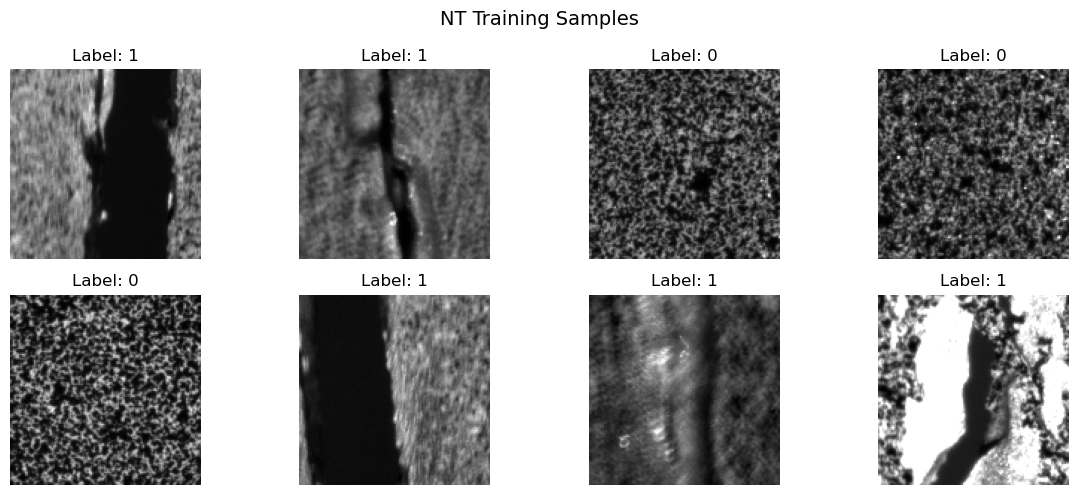

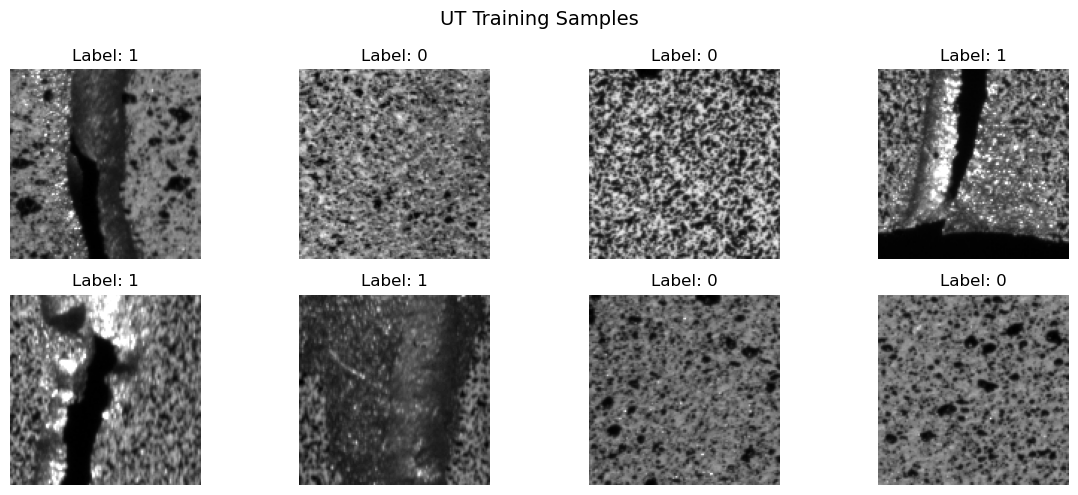

In [6]:
# Load and visualize samples from each category
for cat in ["ASB", "NT", "UT"]:
    data = np.load(f"../data/processed/{cat}/train.npz")
    show_samples(data["images"], data["labels"], title=f"{cat} Training Samples")

## 4. Using with PyTorch DataLoader

The simplest way to use this data with PyTorch is using `TensorDataset` and `DataLoader`.

In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

In [8]:
def load_dataset(category: str, split: str) -> TensorDataset:
    """Load a dataset split as a PyTorch TensorDataset."""
    data = np.load(f"../data/processed/{category}/{split}.npz")
    images = torch.from_numpy(data["images"])
    labels = torch.from_numpy(data["labels"])
    return TensorDataset(images, labels)

# Example: Load ASB dataset
train_dataset = load_dataset("ASB", "train")
val_dataset = load_dataset("ASB", "val")
test_dataset = load_dataset("ASB", "test")

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 2244
Val dataset size: 748
Test dataset size: 749


In [9]:
# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test iteration
for batch_images, batch_labels in train_loader:
    print(f"Batch images shape: {batch_images.shape}")  # (32, 1, 128, 128)
    print(f"Batch labels shape: {batch_labels.shape}")  # (32,)
    print(f"Image dtype: {batch_images.dtype}")
    print(f"Label dtype: {batch_labels.dtype}")
    break

Batch images shape: torch.Size([32, 1, 128, 128])
Batch labels shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


## 5. Custom PyTorch Dataset Class

For more flexibility (e.g., adding data augmentation), you can create a custom Dataset class.

In [10]:
from torch.utils.data import Dataset
from typing import Optional, Callable

class ImageClassificationDataset(Dataset):
    """Custom PyTorch Dataset for image classification."""
    
    def __init__(
        self, 
        category: str, 
        split: str, 
        data_dir: str = "../data/processed",
        transform: Optional[Callable] = None
    ):
        """
        Args:
            category: One of 'ASB', 'NT', 'UT'
            split: One of 'train', 'val', 'test'
            data_dir: Path to the processed data directory
            transform: Optional transform to apply to images
        """
        data_path = Path(data_dir) / category / f"{split}.npz"
        data = np.load(data_path)
        
        self.images = data["images"]
        self.labels = data["labels"]
        self.transform = transform
        self.category = category
        self.split = split
    
    def __len__(self) -> int:
        return len(self.labels)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        image = torch.from_numpy(self.images[idx])
        label = torch.tensor(self.labels[idx])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    def __repr__(self) -> str:
        return f"ImageClassificationDataset(category='{self.category}', split='{self.split}', size={len(self)})"

In [11]:
# Example usage with custom Dataset
train_dataset = ImageClassificationDataset("ASB", "train")
print(train_dataset)

# Get a single sample
image, label = train_dataset[0]
print(f"\nSingle sample:")
print(f"  Image shape: {image.shape}")
print(f"  Label: {label}")

ImageClassificationDataset(category='ASB', split='train', size=2244)

Single sample:
  Image shape: torch.Size([1, 128, 128])
  Label: 1


## 6. Example: Adding Data Augmentation

Using torchvision transforms with the custom Dataset.

In [12]:
import torchvision.transforms as T

# Define augmentation transforms
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

# Create dataset with transforms
train_dataset_aug = ImageClassificationDataset(
    category="ASB", 
    split="train", 
    transform=train_transform
)

# Test augmentation
image_aug, label = train_dataset_aug[0]
print(f"Augmented image shape: {image_aug.shape}")

Augmented image shape: torch.Size([1, 128, 128])


## 7. Quick Model Training Example

A minimal example showing how to train a simple CNN on this dataset.

In [13]:
import torch.nn as nn
import torch.optim as optim

# Simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, 2)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Create model
model = SimpleCNN()
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


In [14]:
# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Load data
train_dataset = load_dataset("ASB", "train")
val_dataset = load_dataset("ASB", "val")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Using device: cuda


In [15]:
# Quick training loop (just 2 epochs for demonstration)
NUM_EPOCHS = 2

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Print metrics
    train_acc = 100 * train_correct / len(train_dataset)
    val_acc = 100 * val_correct / len(val_dataset)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc:.2f}%")

Epoch 1/2
  Train Loss: 0.6925, Acc: 51.96%
  Val Loss: 0.6901, Acc: 53.61%
Epoch 2/2
  Train Loss: 0.6914, Acc: 53.61%
  Val Loss: 0.6900, Acc: 53.61%


## Summary

This notebook demonstrated:
1. **Loading data** from NPZ files
2. **Inspecting** dataset statistics and class distributions
3. **Visualizing** sample images
4. **Using `TensorDataset`** for quick PyTorch integration
5. **Creating a custom `Dataset`** class for more flexibility
6. **Adding data augmentation** with torchvision transforms
7. **Training a simple CNN** model

The data is ready to use for your image classification project!